# MNIST handwritten digits classification with MLPs

In this notebook, we'll train a multi-layer perceptron model to classify MNIST digits using **PyTorch**. 

First, the needed imports. 

In [1]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    
print('Using PyTorch version:', torch.__version__, ' Device:', device)

Using PyTorch version: 2.7.1+cu118  Device: cuda


## Data

Next we'll load the MNIST data.  First time we may have to download the data, which can take a while.

Note that we are here using the MNIST test data for *validation*, instead of for testing the final model.

In [2]:
batch_size = 32

train_dataset = datasets.MNIST('./data', 
                               train=True, 
                               download=True, 
                               transform=transforms.ToTensor())

validation_dataset = datasets.MNIST('./data', 
                                    train=False, 
                                    transform=transforms.ToTensor())

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, 
                                                batch_size=batch_size, 
                                                shuffle=False)

The train and test data are provided via data loaders that provide iterators over the datasets. The first element of training data (`X_train`) is a 4th-order tensor of size (`batch_size`, 1, 28, 28), i.e. it consists of a batch of images of size 1x28x28 pixels. `y_train` is a vector containing the correct classes ("0", "1", ..., "9") for each training digit.

In [3]:
for (X_train, y_train) in train_loader:
    print('X_train:', X_train.size(), 'type:', X_train.type())
    print('y_train:', y_train.size(), 'type:', y_train.type())
    break

X_train: torch.Size([32, 1, 28, 28]) type: torch.FloatTensor
y_train: torch.Size([32]) type: torch.LongTensor


Here are the first 10 training digits:

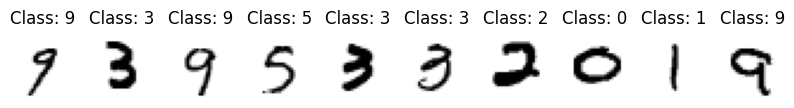

In [4]:
pltsize=1
plt.figure(figsize=(10*pltsize, pltsize))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.axis('off')
    plt.imshow(X_train[i,:,:,:].numpy().reshape(28,28), cmap="gray_r")
    plt.title('Class: '+str(y_train[i].item()))

## MLP network definition

Let's define the network as a Python class.  We have to write the `__init__()` and `forward()` methods, and PyTorch will automatically generate a `backward()` method for computing the gradients for the backward pass.

Finally, we define an optimizer to update the model parameters based on the computed gradients.  We select *stochastic gradient descent (with momentum)* as the optimization algorithm, and set *learning rate* to 0.01.  Note that there are [several different options](http://pytorch.org/docs/optim.html#algorithms) for the optimizer in PyTorch that we could use instead of *SGD*.

In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 100)  # weight: [28*28, 50]   bias: [50, ]
        self.fc1_drop = nn.Dropout(0.2)
        self.fc2 = nn.Linear(100, 80)
        self.fc2_drop = nn.Dropout(0.2)
        self.fc3 = nn.Linear(80, 10)
        
#         self.relu1 = nn.ReLU() 

    def forward(self, x):
        x = x.view(-1, 28*28)   # [32, 28*28]
        x = F.relu(self.fc1(x))
        x = self.fc1_drop(x)
        x = F.relu(self.fc2(x))
        x = self.fc2_drop(x)   # [32, 10]
        return F.log_softmax(self.fc3(x), dim=1)

model = Net().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
criterion = nn.CrossEntropyLoss()

print(model)

Net(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (fc1_drop): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=100, out_features=80, bias=True)
  (fc2_drop): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=80, out_features=10, bias=True)
)


## Learning

Let's now define functions to `train()` and `validate()` the model. 

In [6]:
def train(epoch, log_interval=200):
    # Set model to training mode
    model.train()
    
    # Loop over each batch from the training set
    for batch_idx, (data, target) in enumerate(train_loader):
        # Copy data to GPU if needed
        data = data.to(device)
        target = target.to(device)

        # Zero gradient buffers
        optimizer.zero_grad() 
        
        # Pass data through the network
        output = model(data)

        # Calculate loss
        loss = criterion(output, target)

        # Backpropagate
        loss.backward()  
        
        # Update weights
        optimizer.step()    #  w - alpha * dL / dw
        
        if batch_idx % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.data.item()))

In [7]:
def validate(loss_vector, accuracy_vector):
    model.eval()
    val_loss, correct = 0, 0
    for data, target in validation_loader:
        data = data.to(device)
        target = target.to(device)
        output = model(data)
        val_loss += criterion(output, target).data.item()
        pred = output.data.max(1)[1] # get the index of the max log-probability
        correct += pred.eq(target.data).cpu().sum()

    val_loss /= len(validation_loader)
    loss_vector.append(val_loss)

    accuracy = 100. * correct.to(torch.float32) / len(validation_loader.dataset)
    accuracy_vector.append(accuracy)
    
    print('\nValidation set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        val_loss, correct, len(validation_loader.dataset), accuracy))


Now we are ready to train our model using the `train()` function.  An *epoch* means one pass through the whole training data. After each epoch, we evaluate the model using `validate()`. 

In [8]:
%%time
epochs = 2

lossv, accv = [], []
for epoch in range(1, epochs + 1):
    train(epoch)
    validate(lossv, accv)

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305260


Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.089801


Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.373565


Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.679195


Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.714988


...

Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.322646


Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.165409


Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.187201


Train Epoch: 2 [57600/60000 (96%)]	Loss: 0.344292



Validation set: Average loss: 0.2472, Accuracy: 9288/10000 (93%)

CPU times: total: 33.3 s
Wall time: 37.8 s


Let's now visualize how the training progressed. 

* *Loss* is a function of the difference of the network output and the target values.  We are minimizing the loss function during training so it should decrease over time.
* *Accuracy* is the classification accuracy for the test data.

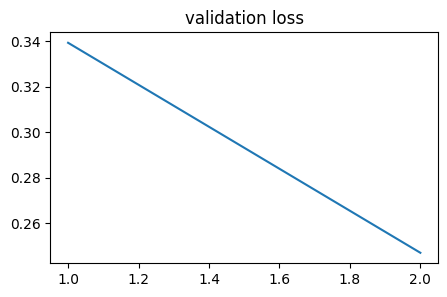

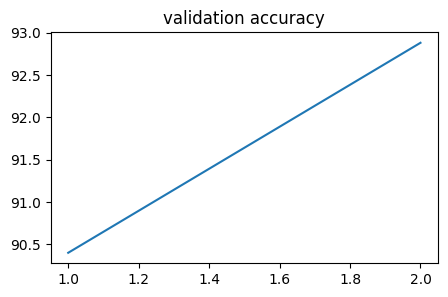

In [9]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), lossv)
plt.title('validation loss')

plt.figure(figsize=(5,3))
plt.plot(np.arange(1,epochs+1), accv)
plt.title('validation accuracy');

## Model tuning

Modify the MLP model.  Try to improve the classification accuracy, or experiment with the effects of different parameters.  If you are interested in the state-of-the-art performance on permutation invariant MNIST, see e.g. this [recent paper](https://arxiv.org/abs/1507.02672) by Aalto University / The Curious AI Company researchers.

You can also consult the PyTorch documentation at http://pytorch.org/.

### 自由探索：改进 MLP

在基线 MLP（隐藏层 [100, 80]、Dropout 0.2、SGD、2 个 epoch，验证准确率约 93%）的基础上，
我们系统比较几种常见改进对验证准确率的影响，控制变量、统一训练 10 个 epoch：

- **A 基线**：[100, 80] + SGD（lr=0.01, momentum=0.5）
- **B 增大容量**：加宽加深为 [512, 256, 128] + SGD
- **C 更换优化器**：基线结构，SGD → Adam（lr=1e-3）
- **D 组合**：[512, 256, 128] + Adam + BatchNorm


In [10]:
import time

class MLP(nn.Module):
    """可配置 MLP：隐藏层宽度、Dropout、是否加 BatchNorm 均可调。"""
    def __init__(self, hidden=(100, 80), dropout=0.2, batchnorm=False):
        super().__init__()
        dims = [28 * 28, *hidden]
        layers = []
        for i in range(len(hidden)):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if batchnorm:
                layers.append(nn.BatchNorm1d(dims[i + 1]))
            layers.append(nn.ReLU(inplace=True))
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        self.features = nn.Sequential(*layers)
        self.out = nn.Linear(dims[-1], 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.out(self.features(x))


def run_experiment(hidden, dropout, opt_name, lr, batchnorm=False, epochs=10):
    """训练一个配置，返回最佳验证准确率(%)和参数量。复用上文的 train_loader / validation_loader / device。"""
    net = MLP(hidden, dropout, batchnorm).to(device)
    opt = (torch.optim.SGD(net.parameters(), lr=lr, momentum=0.5) if opt_name == "sgd"
           else torch.optim.Adam(net.parameters(), lr=lr))
    crit = nn.CrossEntropyLoss()
    best = 0.0
    for ep in range(epochs):
        net.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt.zero_grad(); crit(net(data), target).backward(); opt.step()
        net.eval(); correct = 0
        with torch.no_grad():
            for data, target in validation_loader:
                data, target = data.to(device), target.to(device)
                correct += net(data).argmax(1).eq(target).sum().item()
        best = max(best, 100.0 * correct / len(validation_loader.dataset))
    return best, sum(p.numel() for p in net.parameters())

In [11]:
configs = [
    ("A baseline [100,80] SGD",      dict(hidden=(100, 80),       dropout=0.2, opt_name="sgd",  lr=0.01)),
    ("B wider/deeper [512,256,128]", dict(hidden=(512, 256, 128), dropout=0.2, opt_name="sgd",  lr=0.01)),
    ("C baseline + Adam",            dict(hidden=(100, 80),       dropout=0.2, opt_name="adam", lr=1e-3)),
    ("D [512,256,128]+Adam+BN",      dict(hidden=(512, 256, 128), dropout=0.2, opt_name="adam", lr=1e-3, batchnorm=True)),
]
results = []
for name, cfg in configs:
    acc, npar = run_experiment(**cfg)
    results.append((name, acc, npar))
    print(f"{name:30s}  val_acc={acc:5.2f}%   params={npar/1e3:6.1f}k")

A baseline [100,80] SGD         val_acc=97.10%   params=  87.4k


B wider/deeper [512,256,128]    val_acc=97.72%   params= 567.4k


C baseline + Adam               val_acc=97.64%   params=  87.4k


D [512,256,128]+Adam+BN         val_acc=98.49%   params= 569.2k


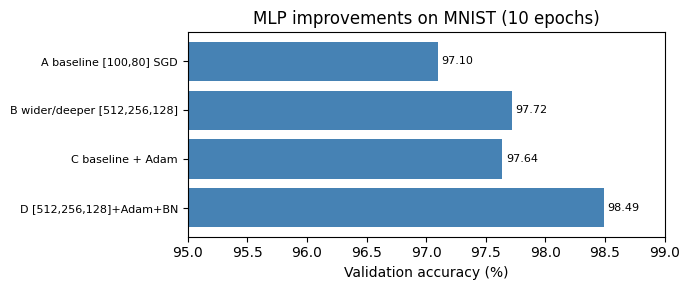

In [12]:
labels = [r[0] for r in results]
accs = [r[1] for r in results]
plt.figure(figsize=(7, 3))
bars = plt.barh(range(len(labels)), accs, color="steelblue")
plt.yticks(range(len(labels)), labels, fontsize=8)
plt.xlim(95, 99)
plt.xlabel("Validation accuracy (%)")
plt.title("MLP improvements on MNIST (10 epochs)")
for i, a in enumerate(accs):
    plt.text(a + 0.03, i, f"{a:.2f}", va="center", fontsize=8)
plt.gca().invert_yaxis(); plt.tight_layout()

### 小结

本次运行（10 epoch，batch=32）结果：

| 配置 | 验证准确率 | 参数量 |
|------|----------|--------|
| A 基线 [100,80] + SGD | 97.10% | 87.4k |
| B 加宽加深 [512,256,128] + SGD | 97.72% | 567k |
| C 基线 + Adam | 97.64% | 87.4k |
| D [512,256,128] + Adam + BatchNorm | **98.49%** | 569k |

- **训练充分性是首要因素**：基线由原 notebook 的 2 epoch（约 93%）延长到 10 epoch 即达约 97%，欠拟合是原始基线最主要的短板。
- **单项改进收益有限且相近**：加宽加深（B，+0.62%）与改用 Adam（C，+0.54%）相对基线提升接近；其中 **Adam 在不增加任何参数的前提下，达到与参数量 6.5 倍的宽网络相当的效果，性价比明显更高**。
- **组合 + BatchNorm 最优**：三者叠加（D）达到 98.49%，比基线提升约 1.4%，是所有配置中最好的。
- **结论**：在 MNIST 上，充分训练加上合适的优化器/归一化组合，比单纯堆叠参数更划算。
